# Assignment 2 - Numbers to Neurons

---
> Complete each question below. Write theory answers in Markdown cells and code in code cells.

In [2]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

---
## Q1 - Perceptrons and Sigmoid Neurons

### Q1a - NAND Perceptron

Write a Python class using NumPy that implements a **NAND logic gate** using a single perceptron. Your implementation must use **vectorized operations** (no explicit `for` loops in the activation function) to process an input matrix of shape `(N, 2)` and return the corresponding binary outputs.

Mathematically determine and set the correct weights and bias within your code.

In [3]:
#code here
class PerceptronNAND:

  def __init__(self):
    self.weights = np.array([-2.0,-2.0])
    self.bias = 3.0

  def step_activation(self,x):
    return np.where(x>=0,1,0)

  def operate(self,inp):
    inp = np.asarray(inp)
    out = np.dot(inp,self.weights) + self.bias
    return self.step_activation(out)

if __name__ == "__main__":

  eg = np.array([[0,0],[1,0],[0,1],[1,1]])
  nand = PerceptronNAND()
  res = nand.operate(eg)

  for a,b in zip(eg,res):
    print(a[0],'nand',a[1],'=',b)

0 nand 0 = 1
1 nand 0 = 1
0 nand 1 = 1
1 nand 1 = 0


### Q1b - Perceptron Sensitivity

Explain precisely why a tiny change in one weight can cause **chaos** in a perceptron network. What property of the perceptron makes this happen?

> **Your answer:**

Perceptrons use a completely dicontinuous Heaviside step function as activation function.Even if the weighted sum (z) is barely below 0 (say -0.0001) the output is 0 and if due to a small change if the weighted sum goes just above 0 (say 0.0001) to output suddenly leaps to 1. Since the output of this neuron goes as input of multiple neuron of next layer, this sudden massive leap of input might push this next layer neurons across their respective threshold causing them to flip from 0 to 1 or vice-versa. These changes propagates till final neuron, causing tiny change in weight and bises to completely flip the network's final classification or prediction.

The property of Perceptron is its binary nature due to Heaviside step function as its activation function.

### Q1c - Sigmoid to Perceptron Limit

Suppose you multiply all the weights and bias of a sigmoid neuron by a positive constant c > 0.

1. As c approaches what value will this sigmoid neuron behave exactly like a classic perceptron? Why mathematically?
2. Explain in 2-3 lines why we prefer sigmoid neurons over perceptrons.

> **Your answer:**

1.As c --> +∞ , the sigmoid neuron behaves exactly like perceptron neuron.\
if z>0 : e^(-cz) --> 0 and sigmoid function --> 1,\
if z<0 : e^(-cz) --> ∞ and sigmoid function --> 0

2.Sigmoid Neurons are modified Perceptrons so that Small change in their weights and biases makes only small change in output. The Activation function of Sigmoid Neurons is a smooth curve so that Δoutput is a linear function of Δwᵢ and Δbᵢ in weights and biases respectively. This linearity makes it easy to choose small changes in input to acheive any desired small changes in output.

---
## Q2 - The Quadratic Cost Function

$$C(w,b) = \frac{1}{2n} \sum_x \|y(x) - a\|^2$$

### Q2a - The Factor of 1/2

Why is there a factor of 1/2 in front? Derive why it is mathematically convenient when computing the derivative of C with respect to any weight w.

> **Your answer:**

Let's define the error for a single training example as $C_x$:$$C_x = \frac{1}{2} \|y(x) - a\|^2$$.

$$\frac{\partial C_x}{\partial w_{jk}} = \frac{\partial C_x}{\partial a_j} \cdot \frac{\partial a_j}{\partial z_j} \cdot \frac{\partial z_j}{\partial w_{jk}}$$.

$$\frac{\partial C_x}{\partial a_j} = \frac{\partial}{\partial a_j} \left[ \frac{1}{2} (y_j - a_j)^2 \right]$$.


$$\frac{\partial C_x}{\partial a_j} = \frac{1}{2} \cdot 2(y_j - a_j)^{2-1} \cdot \frac{\partial}{\partial a_j}(y_j - a_j)$$$$\frac{\partial C_x}{\partial a_j} = \frac{1}{2} \cdot 2(y_j - a_j) \cdot (-1)$$$$\frac{\partial C_x}{\partial a_j} = -(y_j - a_j) = (a_j - y_j)$$.


While taking derivative the of the square term, the result has a factor 2, which gets cancelled by the 1/2 in front, giving us a cleaner mathematical expression.

### Q2b - Computing C by Hand

A network has two training examples:
- Example 1: output = 0.9, target = 1.0
- Example 2: output = 0.3, target = 0.0

Compute C by hand and explain what the value tells you about network performance.

> **Your answer:**\begin{align*}
c = \frac{1}{2*2}  [ (1.0-0.9)^2 + (0.0-0.3)^2 ]
 =  \frac{1}{4} [0.01+0.09]
 =0.025 \end{align*}

 > The cost function tells how much error the network does while predicting the output. Since the output is near zero, the network's output matches closely with the expected output of the data-set.

In [4]:
# Verify your hand computation
outputs = np.array([0.9, 0.3])
targets = np.array([1.0, 0.0])

C_val = np.sum(np.square(targets-outputs)) / 4  # TODO: compute C
print(f'C = {C_val}')

C = 0.024999999999999998


### Q2c - Cost vs Accuracy

Explain why we use a cost function and do **not** directly maximise classification accuracy.

> **Your answer:**
The classification accuracy( the no. of images correctly classified) is not a smooth function of weights and biases in the network. Sometimes making small change in weights and biases wont make any change in it at all. So it is difficult to figure out how to change the weights and biases for improvement. Using a smooth cost function is easier to figure out how to make small change in weights and biases to get improvement.

### Q2d - Absolute Error vs Squared Error

An alternative cost is the absolute error: C = (1/n) * sum |y(x) - a|.

Explain **one mathematical problem** with using absolute error instead of squared error, specifically when doing gradient descent.

> **Your answer:**
The problem is that absolute error function is not differentiable at y(x) = a and derivative of this function is always a fixed constant(+1 or -1). Whereas,
the squared error function is differentiable everywhere and its derivative is proportional to the error itself.

---
## Q3 - Gradient Descent on a Toy Cost Function

$$C(w, b) = (w - 3)^2 + 2(b - 1)^2$$

### Q3a - Minimum by Inspection

By inspection, what values of w and b minimise C? What is the minimum value of C? Explain your reasoning without calculus.

> **Your answer:**
> for w = 3, b = 1 the C(w,b) is minimum.
>
> the minimum(c(w,b)) = 0
>
> Since C is the sum of squares, its minimum is 0, which is attained when each of the 2 enities being squared becomes 0.


### Q3b - Two Steps by Hand

Compute dC/dw and dC/db. Starting from (w, b) = (0, 0) with learning rate eta = 0.1, show the first two gradient descent update steps by hand. Where does the parameter vector end up after step 2?

> **Your answer:**
>$$ \frac{dc}{dw} = 2(w-3)$$

>$$\frac{dc}{db} = 4(b-1)$$

>at (0,0)
>$$ \frac{dc}{dw} = 2(-3) = -6 $$
>$$ \frac{dc}{db} = 4(-1) = -4 $$
>$$ w_1 = w - η\frac{dc}{dw} = 0 - 0.1(-6) = 0.6  $$
>$$ b_1 = b - η\frac{dc}{db} = 0 - 0.1(-4) = 0.4  $$
>
>$$ (w_1,b_1) = (0.6,0.4) ,  C(w_1,b_1) = 6.48 $$
>
>at (0.6, 0.4)
>$$ \frac{dc}{dw} = -4.8, \frac{dc}{db} = -2.4 $$
>$$ w_2 = 0.6 - 0.1(-4.8) = 1.08  $$
>
>$$ b_2 = 0.4 - 0.1(-2.4) = 0.64  $$
>
>$$ (w_2,b_2) = (1.08,0.64) , C(w_2,b_2) = 3.9456 $$
>


In [5]:
def cost(w, b):
    return (w - 3)**2 + 2*(b - 1)**2

def grad_cost(w, b):
    dw = 2*(w - 3)  # TODO
    db = 4*(b - 1)  # TODO
    return dw, db

# Verify your hand calculation
eta = 0.1
w, b = 0.0, 0.0
for step in range(1, 3):
    dw, db = grad_cost(w, b)
    w = w - eta * dw
    b = b - eta * db
    print(f'Step {step}: w={w:.4f}, b={b:.4f}, C={cost(w,b):.4f}')

Step 1: w=0.6000, b=0.4000, C=6.4800
Step 2: w=1.0800, b=0.6400, C=3.9456


### Q3c - Too-Large Learning Rate

If you set eta = 0.6, what goes wrong on the b update? Show numerically. What does this tell you about learning rate selection?

> **Your answer:**
$$\frac{\partial C}{\partial b} = 4(b - 1)$$
$$b_{t+1} = b_t - \eta \frac{\partial C}{\partial b}$$
Substituting $\eta = 0.6$:
$$b_{t+1} = b_t - 0.6 \cdot 4(b_t - 1)$$$$b_{t+1} = b_t - 2.4(b_t - 1)$$
Distance from optimum b* = 1
$$b_{t+1} - 1 = b_t - 1 - 2.4(b_t - 1)$$$$b_{t+1} - 1 = -1.4(b_t - 1)$$
This shows that at each iteration, the error (distance from the optimum $b^*=1$) is multiplied by $-1.4$.

>For example, let's start with $b_0$ = 0 \:
Iteration 1:$$b_1 = 2 - 2.4(2 - 1) = -0.4$$Error: $-0.4 - 1 = -1.4$

>Iteration 2:$$b_2 = -0.4 - 2.4(-0.4 - 1) = 2.96$$Error: $2.96 - 1 = +1.96$

>Iteration 3:$$b_3 = 2.96 - 2.4(2.96 - 1) = -1.744$$Error: $-1.744 - 1 = -2.744$

>Iteration 4:$$b_4 = -1.744 - 2.4(-1.744 - 1) = 4.8416$$Error: $4.8416 - 1 = +3.8416$

>**Upper Bound for Stability**: For a quadratic cost function, gradient descent only converges if the learning rate satisfies $\eta < \frac{2}{L}$, where $L$ is the second derivative (or maximum eigenvalue of the Hessian matrix) along that dimension. Here, $\frac{\partial^2 C}{\partial b^2} = 4$, meaning the maximum stable learning rate for $b$ is $\eta < \frac{2}{4} = 0.5$. Setting $\eta = 0.6$ exceeds this stability threshold.

In [6]:
eta_bad = 0.6
w, b = 0.0, 0.0
for step in range(1, 5):
    dw, db = grad_cost(w, b)
    w = w - eta_bad * dw
    b = b - eta_bad * db
    print(f'Step {step}: w={w:.4f}, b={b:.4f}, C={cost(w,b):.4f}')

Step 1: w=3.6000, b=2.4000, C=4.2800
Step 2: w=2.8800, b=-0.9600, C=7.6976
Step 3: w=3.0240, b=3.7440, C=15.0596
Step 4: w=2.9952, b=-2.8416, C=29.5158


---
## Q4 - Sigmoid Neuron: Implementation and Visualisation

In [7]:
class SigmoidNeuron:

    def __init__(self, weights, bias):
        self.weights = np.array(weights, dtype=float)
        self.bias = float(bias)

    def forward(self, x):
        # TODO: compute z = w.x + b, return sigmoid(z)
        z = np.dot(self.weights,x) +  self.bias
        sig_z = 1.0 / (1.0 + np.exp(-z))
        return sig_z

    def numerical_gradient(self, x, h=1e-5):
        # TODO: centered difference (f(x+h) - f(x-h)) / 2h
        grad = ( self.forward(x+h) - self.forward(x-h) ) / (2*h)
        grad_weights = grad*x
        grad_bias = grad*1
        return (grad_weights, grad_bias)

### Q4a - Forward Pass and Gradients

For weights=[2, -1] and bias=0.5, compute the output and all gradients at x=[1, 1]. Explain what the gradient w.r.t. w1 means in plain English.

In [8]:
neuron = SigmoidNeuron(weights=[2, -1], bias=0.5)
x = np.array([1.0, 1.0])

output = neuron.forward(x)
grad_w, grad_b = neuron.numerical_gradient(x)

print(f'Output:        {output}')
print(f'd(output)/dw1: {grad_w[0]:.6f}')
print(f'd(output)/dw2: {grad_w[1]:.6f}')
print(f'd(output)/db:  {grad_b:.6f}')

Output:        0.8175744761936437
d(output)/dw1: 0.149146
d(output)/dw2: 0.149146
d(output)/db:  0.149146


**Explanation of gradient w.r.t. w1:**

> **Your answer:**
>Gradient w.r.t. w1 means how much the function(here sigmoid function) changes for a small change in w for w = w1 = 2.

### Q4b - Plot sigma(z) and sigma'(z)

Plot sigma(z) and its derivative sigma'(z) = sigma(z)(1 - sigma(z)) for z in [-10, 10].

- At what value of z is the gradient largest?
- What happens as z approaches +/- infinity and why is this a problem (vanishing gradient)?

> **Your answer:**

/tmp/ipykernel_5295/583729991.py:12: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


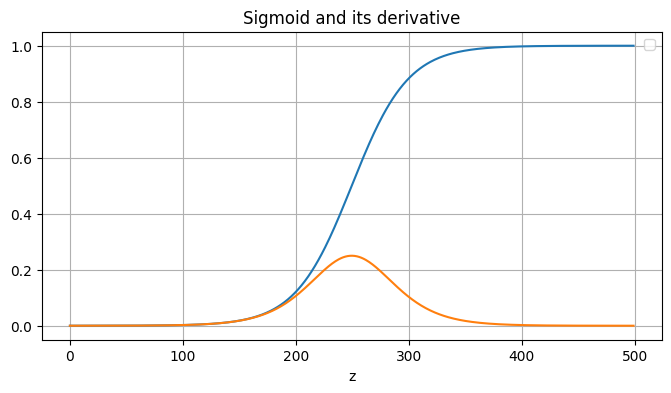

In [9]:
z = np.linspace(-10, 10, 500)

# TODO: compute sigma and sigma_prime
sigma       = 1.0 / (1.0 + np.exp(-z))
sigma_prime = sigma * (1 - sigma)

plt.figure(figsize=(8, 4))
# TODO: plot both curves
plt.plot(sigma)
plt.plot(sigma_prime)
plt.xlabel('z')
plt.legend()
plt.title('Sigmoid and its derivative')
plt.grid(True)
plt.show()

### Q4c - Is sigma(100z) basically a perceptron?

A classmate claims: 'a sigmoid neuron with weights multiplied by 100 is basically the same as a perceptron.'

Plot sigma(100z) vs sigma(z) vs the step function. Is the claim correct? Under what condition does it break down?

> **Your answer:**
> The claim is almost correct because sigma(100z) behaves like step function for most of the positive and negative values. This breaks down when the value 'z' is close to or equal to 0. The step function which is discontinuous,suddenly drops across 0, whereas the sigmoid function is continuous and has a value of 0.5 at 0. When z is very close to 0 (like 0.01) the sigmoid function gives 0.731, which is invalid output of step function.

/tmp/ipykernel_5295/2751998457.py:15: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


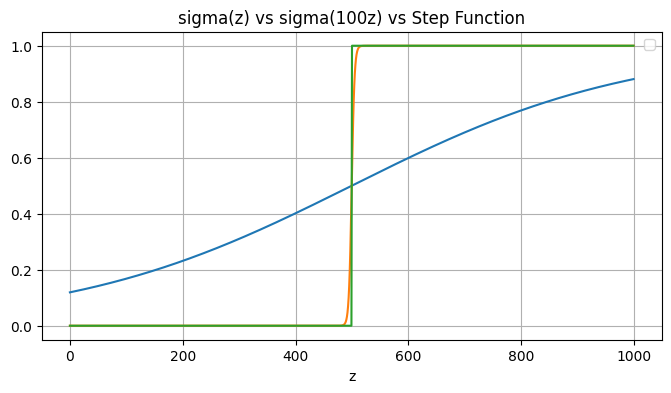

In [10]:
z = np.linspace(-2, 2, 1000)

# TODO: compute sigma(z), sigma(100*z), step function
sigma       = 1.0 / (1.0 + np.exp(-z))
sigma_100       = 1.0 / (1.0 + np.exp(-100*z))
step = np.where(z>0,1,0)

plt.figure(figsize=(8, 4))
# TODO: plot all three
plt.plot(sigma)
plt.plot(sigma_100)
plt.plot(step)
plt.title('sigma(z) vs sigma(100z) vs Step Function')
plt.xlabel('z')
plt.legend()
plt.grid(True)
plt.show()

---
## Q5 - Gradient Descent on a Toy Regression Problem

A single-layer network (one input, one output, no activation) must learn y = 3x + 1.

In [11]:
X_train = np.array([0.0, 1.0, 2.0, 3.0, 4.0])
y_train = np.array([1.0, 4.0, 7.0, 10.0, 13.0])

### Q5a - Analytical Gradients + Full-Batch GD

Derive dC/dw and dC/db analytically (show algebra). Implement full-batch GD with eta = 0.01 for 200 epochs. Plot the loss curve. Do w and b converge to 3 and 1?

**Derivation (show algebra):**

> **Your answer:**
>$$ C(w,b) = \frac{1}{2N} \sum_{i=1}^{N} (\hat{y}_i - y_i)^2, $$\
>$\hat{y}_i$ -> y with current (w,b) , $y_i$ -> True y value
>$$\frac{\partial C}{\partial w} = \frac{1}{N} \sum_{i=1}^{N} (\hat{y}_i - y_i) \cdot x_i$$
>$$\frac{\partial C}{\partial b} = \frac{1}{N} \sum_{i=1}^{N} (\hat{y}_i - y_i)$$


Final w = 2.9910, b = 1.0256


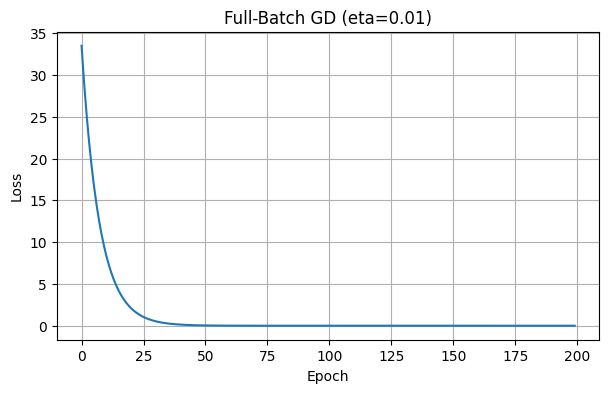

In [12]:
w, b = 0.0, 0.0
eta = 0.01
losses = []
N = len(X_train)

for epoch in range(200):
    # TODO: predictions, loss, gradients, update
    y_pred = w*X_train + b

    dw = (1/N) * np.sum( (y_pred - y_train) * X_train)
    db = (1/N) * np.sum( y_pred - y_train )

    w -= eta*dw
    b -= eta*db

    loss = (1/(2*N)) * np.sum( (y_pred - y_train)**2 )
    losses.append(loss)

print(f'Final w = {w:.4f}, b = {b:.4f}')
plt.figure(figsize=(7, 4))
plt.plot(losses)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Full-Batch GD (eta=0.01)')
plt.grid(True)
plt.show()

### Q5b - SGD with Mini-Batch Size = 1

Implement SGD with batch size 1. Train 200 epochs with eta = 0.01. Plot the loss curve. How does it differ from full-batch? Explain in terms of gradient quality and noise.

> **Your answer:**
>
>**Gradient Quality :**  full batch gradient descent computes exact gradient of the cost function across all training data, and the gradient vector points exactly in the direction of steepest descent for the global dataset.
The SGD calculates a heavily approximated gradient based on only one randomly selected data at a time. At any time the update given by any single data might differ significantly from the true global minimum.
>
>**Noise :** For full batch,Because the gradient quality is perfect, the optimization path is completely smooth, monotonic and deterministic. Loss curve drops smoothly towards zero without any fluctuation.
>For SDG,Because each single-sample update is imperfect, a significant amount of stochastic noise is introduced into the training trajectory. When looking closely at the loss curve, SGD exhibits noticeable fluctuations and oscillations.

Final w = 2.9994, b = 1.0018


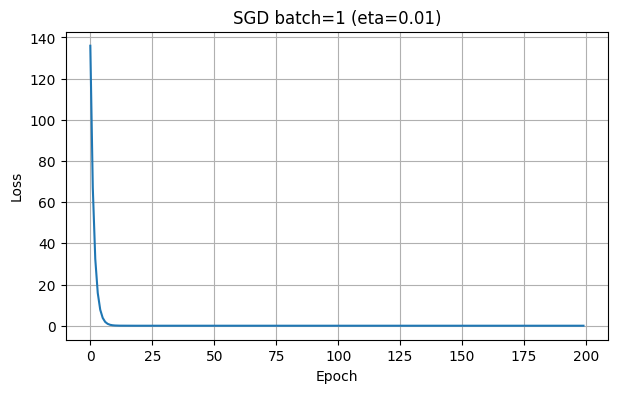

In [13]:
w, b = 0.0, 0.0
eta = 0.01
losses_sgd = []
N = len(X_train)


for epoch in range(200):
    # TODO: pick random example, compute gradient, update
    loss = 0
    indices = np.arange(N)
    np.random.shuffle(indices)

    for i in indices :
      y_true = y_train[i]
      x = X_train[i]

      y_pred = w * x + b

      loss += 0.5 * (y_pred - y_true) **2

      dw = (y_pred - y_true) * x
      db = (y_pred - y_true)

      w -= eta * dw
      b -= eta * db

    losses_sgd.append(loss)

print(f'Final w = {w:.4f}, b = {b:.4f}')
plt.figure(figsize=(7, 4))
plt.plot(losses_sgd)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('SGD batch=1 (eta=0.01)')
plt.grid(True)
plt.show()

### Q5c - Divergence with eta = 0.5

Set eta = 0.5 with full-batch GD. Show the loss curve and explain using the gradient formulas from Q5a why it diverges.

> **Your answer:**
complete this!!!!!!!!!!

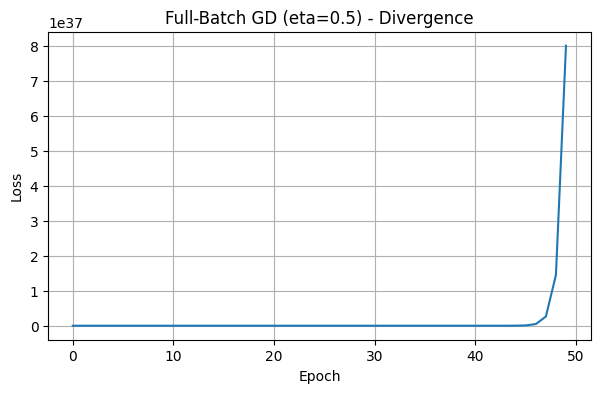

In [14]:
w, b = 0.0, 0.0
losses_div = []
eta = 0.5

for epoch in range(50):
    # TODO: full-batch GD with eta=0.5
    y_pred = w*X_train + b

    dw = (1/N) * np.sum( (y_pred - y_train) * X_train)
    db = (1/N) * np.sum( y_pred - y_train )

    loss = (1/(2*N)) * np.sum( (y_pred - y_train)**2 )
    losses_div.append(loss)

    if loss is not None and not np.isfinite(loss):
        print(f'Diverged at epoch {epoch}')
        break

    w -= eta*dw
    b -= eta*db

plt.figure(figsize=(7, 4))
plt.plot(losses_div)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Full-Batch GD (eta=0.5) - Divergence')
plt.grid(True)
plt.show()

---
## Q6 - One-Hot to 4-Bit Binary Encoding Layer

A network classifies digits 0-9 with a 10-neuron one-hot output. Design a final **4-neuron layer** that converts this into a **4-bit binary** encoding (e.g. digit 5 outputs 0101). Specify the weight matrix and bias vector.

**Design and Reasoning:**

> **Your answer:**
> The threshold here is 0.5. Therefore for a bit to become 1 the input has to be > 0.5 and for 0, input has to be < 0.5.
>Let's consider the Number '1' for example,and let bits be $b_0,b_1,b_2,b_3$.
and input from digits neuron be x.
>There is no noise in these inputs, (i.e) the digit neurons either give 0 or 1.
>For number '1' neuron, the input x = 1, it has to set $b_0$ to 1 and rest to 0.
>let $w_{i,j}$ be the weight between $i^{th}$ bit and $j^{th}$ digit.
>
>So $w_{0,1}.1 + b = w_{0,1} + b > 0.5$
>
>if $w_{0,1}$ = 10 and b = -5, then
>
>$w_{0,1}.1 + b = w_{0,1} + b = 5 > 0.5$
>
>Since x = 0 or 1 is always.
>
> $w_{i,j} = 10$ for bit to be set to 1 and $w_{i,j} = 0 $ for bit to be set to 0.
>
>And b = -5 for all.
>
>For $b_0$ (units digit): Active for odd digits $\{1, 3, 5, 7, 9\}$.
>
>Weights from old neurons: $w_{0,1} = w_{0,3} = w_{0,5} = w_{0,7} = w_{0,9} = 10$. All other weights to $b_0$ are $0$.
>
>For $b_1$ (twos digit): Active for $\{2, 3, 6, 7\}$.
>
>Weights from old neurons: $w_{1,2} = w_{1,3} = w_{1,6} = w_{1,7} = 10$. All other weights to $b_1$ are $0$.
>
>For $b_2$ (fours digit): Active for $\{4, 5, 6, 7\}$.
>
>Weights from old neurons: $w_{2,4} = w_{2,5} = w_{2,6} = w_{2,7} = 10$. All other weights to $b_2$ are $0$.
>
>For $b_3$ (eights digit): Active for $\{8, 9\}$.
>
>Weights from old neurons: $w_{3,8} = w_{3,9} = 10$. All other weights to $b_3$ are $0$.

In [22]:
# TODO: define W (4x10) and b_enc (4,)
W     = np.array([
    [0,10, 0,10, 0,10, 0,10, 0,10],
    [0, 0,10,10, 0, 0,10,10, 0, 0],
    [0, 0, 0, 0,10,10,10,10, 0, 0],
    [0, 0, 0, 0, 0, 0, 0, 0,10,10]
])[::-1]  # shape (4, 10)
b_enc = np.full((4,),-5)  # shape (4,)
def threshold(x):
    return (x >= 0.5).astype(int)

print('Digit | Output | Expected | OK?')
print('-' * 35)
for digit in range(10):
    one_hot = np.zeros(10)
    one_hot[digit] = 1.0
    out = threshold(W @ one_hot + b_enc)
    expected = format(digit, '04b')
    ok = 'OK' if ''.join(map(str, out)) == expected else 'FAIL'
    print(f'  {digit}   |  {out}  |  {expected}  | {ok}')

Digit | Output | Expected | OK?
-----------------------------------
  0   |  [0 0 0 0]  |  0000  | OK
  1   |  [0 0 0 1]  |  0001  | OK
  2   |  [0 0 1 0]  |  0010  | OK
  3   |  [0 0 1 1]  |  0011  | OK
  4   |  [0 1 0 0]  |  0100  | OK
  5   |  [0 1 0 1]  |  0101  | OK
  6   |  [0 1 1 0]  |  0110  | OK
  7   |  [0 1 1 1]  |  0111  | OK
  8   |  [1 0 0 0]  |  1000  | OK
  9   |  [1 0 0 1]  |  1001  | OK


---
## Q7 - Geometric Interpretation of 1D Gradient Descent

Consider C(v) as a function of a single scalar v.

1. Give a precise **geometric interpretation** of the update rule v = v - alpha * dC/dv.
2. How do the slope and the learning rate alpha physically dictate movement along the curve?

> **Your answer:**

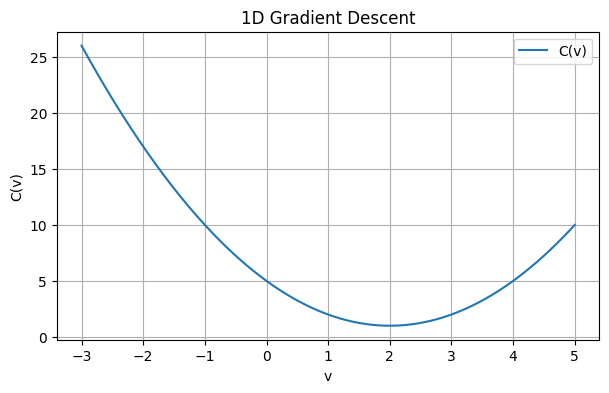

In [23]:
v_vals = np.linspace(-3, 5, 300)
C_v = (v_vals - 2)**2 + 1

# TODO: run gradient descent steps and annotate on the curve
plt.figure(figsize=(7, 4))
plt.plot(v_vals, C_v, label='C(v)')
plt.xlabel('v')
plt.ylabel('C(v)')
plt.title('1D Gradient Descent')
plt.legend()
plt.grid(True)
plt.show()

---
## Q8 - Zero Hidden Layers: What Model Are You Really Training?

Suppose you remove all hidden layers, connecting 784 inputs directly to 10 outputs, trained with SGD.

1. What **mathematical model** have you effectively created?
2. Why is classification accuracy **fundamentally capped**?
3. What does this imply about the **necessity of hidden layers**?

> **Your answer:**